In [13]:
%%time
import datetime
import json
import asyncio

from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager

fablib = fablib_manager()

fablib.show_config();

User: koufalex@gmail.com bastion key is valid!
Configuration is valid


Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
Token File,/home/fabric/.tokens.json
Project ID,49f65ad7-d8a2-4ab9-8ca0-ba777a2e0ea2
Bastion Host,bastion.fabric-testbed.net
Bastion Username,koufalex_0000215529
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub
Slice Private Key File,/home/fabric/work/fabric_config/slice_key


CPU times: user 98.6 ms, sys: 9.5 ms, total: 108 ms
Wall time: 2.62 s


In [15]:
slice = fablib.get_slice(name="DYNAMOS-on-FABRIC");
nodes = slice.get_nodes();
print(nodes)

[<fabrictestbed_extensions.fablib.node.Node object at 0x7d15cc578b10>, <fabrictestbed_extensions.fablib.node.Node object at 0x7d15a86e2410>, <fabrictestbed_extensions.fablib.node.Node object at 0x7d15a8695150>, <fabrictestbed_extensions.fablib.node.Node object at 0x7d15e77f0690>, <fabrictestbed_extensions.fablib.node.Node object at 0x7d15cc235990>, <fabrictestbed_extensions.fablib.node.Node object at 0x7d15cc3bcc90>]


In [16]:
# get nodes and IPs 
def get_ip(node):
    interface = node.get_interface(network_name=f"Network-{node.get_site()}")
    return interface.get_ip_addr()

nodes_dict= dict()

for node in nodes[:]:
    ip = get_ip(node)
    name = node.get_name()
    nodes_dict[name] = {"ip": ip, "node": node}
    print(f"{name}: {ip}")

print(nodes_dict)

control: 10.148.2.2
dynamos: 10.148.2.3
server: 10.148.2.4
clientone: 10.148.2.5
clienttwo: 10.148.2.6
clientthree: 10.148.2.7
{'control': {'ip': '10.148.2.2', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d15cc578b10>}, 'dynamos': {'ip': '10.148.2.3', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d15a86e2410>}, 'server': {'ip': '10.148.2.4', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d15a8695150>}, 'clientone': {'ip': '10.148.2.5', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d15e77f0690>}, 'clienttwo': {'ip': '10.148.2.6', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d15cc235990>}, 'clientthree': {'ip': '10.148.2.7', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d15cc3bcc90>}}


In [4]:
# # For the animation 
# %matplotlib widget
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# from matplotlib.patches import FancyArrowPatch


# def get_animation(block_client3=False):

#     client_positions = [(1, 3), (2, 5), (5, 2)]
#     server_position = (3, 1)
    
#     fig, ax = plt.subplots(figsize=(6, 6))
#     ax.set_xlim(0, 6)
#     ax.set_ylim(0, 6)
#     ax.set_aspect('equal')
#     ax.axis('off')
    
#     # Draw clients and server
#     for i, pos in enumerate(client_positions):
#         ax.add_patch(plt.Circle(pos, 0.2, color='blue'))
#     ax.add_patch(plt.Circle(server_position, 0.3, color='red'))
    
#     # Add labels
#     for idx, pos in enumerate(client_positions, 1):
#         ax.text(pos[0], pos[1]+0.3, f'Client {idx}', ha='center', fontsize=12)
#     ax.text(server_position[0], server_position[1]-0.4, 'Server', ha='center', fontsize=12)
    
#     blocked_idx = 2  # Index of client to block (Client 3)
    
#     # Draw red X for client 3 if blocked
#     if block_client3:
#         bx, by = client_positions[blocked_idx]
#         xsize = 0.2
#         ax.plot([bx-xsize, bx+xsize], [by-xsize, by+xsize], color='red', lw=4)
#         ax.plot([bx-xsize, bx+xsize], [by+xsize, by-xsize], color='red', lw=4)
    
#     # Prepare arrows: one for each client
#     arrows = []
#     for idx, pos in enumerate(client_positions):
#         if block_client3 and idx == blocked_idx:
#             arrows.append(None)
#             continue
#         arrow = FancyArrowPatch(
#             posA=pos, posB=pos,
#             arrowstyle='->', mutation_scale=25, color='green', lw=3
#         )
#         ax.add_patch(arrow)
#         arrows.append(arrow)
    
#     def interpolate(posA, posB, f):
#         return (posA[0] + f*(posB[0]-posA[0]), posA[1] + f*(posB[1]-posA[1]))
    
#     def animate(frame):
#         n_frames = 40
#         phase = (frame % n_frames) / n_frames
#         for idx, pos in enumerate(client_positions):
#             if block_client3 and idx == blocked_idx:
#                 continue  # No arrows for blocked client
#             if phase < 0.5:
#                 # Send: arrows grow from client towards server
#                 f = phase * 2
#                 start = pos
#                 end = interpolate(pos, server_position, f)
#                 arrows[idx].set_positions(start, end)
#                 arrows[idx].set_color('green')
#             else:
#                 # Response: arrows grow from server towards client
#                 f = (phase - 0.5) * 2
#                 start = server_position
#                 end = interpolate(server_position, pos, f)
#                 arrows[idx].set_positions(start, end)
#                 arrows[idx].set_color('orange')
#         # Only returning visible arrows for blitting
#         return [a for a in arrows if a is not None]
    
#     ani = animation.FuncAnimation(fig, animate, frames=80, interval=100, blit=True)
#     return ani


/opt/conda/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


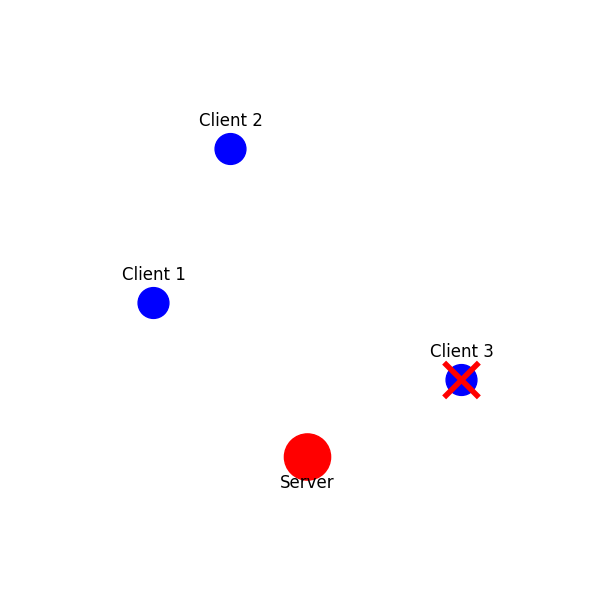

In [5]:
# import time 
# # ani = get_animation(False)
# ani = get_animation(True)
# plt.show()

# time.sleep(3)

# To stop the animation 
# ani.event_source.stop()

In [8]:
# ani.event_source.stop()

In [17]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import time

def plot_accuracy(rounds, accuracies, clients, window=5, show_smoothed=True):
    clear_output(wait=True)
    # Plot accuracy over rounds, color by number of clients
    plt.figure(figsize=(10, 6))

    # Find transition points where number of clients changes
    # We'll split into segments with constant number of clients
    segments = []
    start_idx = 0
    for i in range(1, len(clients)):
        if clients[i] != clients[i - 1]:
            segments.append((start_idx, i, clients[i - 1]))
            start_idx = i
    segments.append((start_idx, len(clients), clients[-1]))

    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    for idx, (start, end, n_clients) in enumerate(segments):
        plt.plot(rounds[start:end], accuracies[start:end], label=f"{n_clients} clients",
                 color=colors[idx % len(colors)])

    plt.xlabel('Training Round')
    plt.ylabel('r2 score')
    plt.title('VFL Training r2 score over training cycles')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.ylim(bottom=0, top=.8)
    plt.show()
        # time.sleep(1)

In [18]:
import json


def trigger_scenario(scenario_no=1):
    if scenario_no == 1:
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/1.trigger_VFL_base.sh", remote_file_path="trigger_VFL.sh")
    elif scenario_no == 2:
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/2.trigger_VFL_removal.sh", remote_file_path="trigger_VFL.sh")
    elif scenario_no == 3:
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/3.trigger_VFL_remove_add.sh", remote_file_path="trigger_VFL.sh")
    elif scenario_no == 4:
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/4.trigger_VFL_backtrack.sh", remote_file_path="trigger_VFL.sh")
    else:
        print(f"scenario_no ({scenario_no}) does not correspond to scenario, defaulting to scenario 1")
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/1.trigger_VFL_base.sh", remote_file_path="trigger_VFL.sh")
    
    res = nodes_dict['control']['node'].execute("bash trigger_VFL.sh")
    
    
    # parse the request id from json 
    res_dict = json.loads(res[0])
    req_id = res_dict['request_id'] 
    # req_id = res_dict['active_request_id'] 
    # req_status = res_dict['status']
    print(req_id)
    # print(req_status)
    # print(type(res[1]))
    
    
    start_time = time.time()
    timeout = 180  # seconds 
    
    while True:
    
        # upload the polling script
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/poll_results.sh", remote_file_path="poll_results.sh")
        
        # POLL RESULTS 
        results = nodes_dict['control']['node'].execute(f"bash poll_results.sh {req_id}", quiet=True)
        
        results_dict = json.loads(results[0])
        # print(results_dict['metadata'])
        # print(results_dict['request_id'])
        # print(results_dict['status'])
        status = results_dict['status']
        # print(results_dict['results'])
        
        accuracies = [k["accuracy"] for k in results_dict['results']]
        # accuracies = [(a if a >0 else 0) for a in accuracies]  # capping negative values to zero  
        
        clients = [k["clients"] for k in results_dict['results']]
        rounds = [k["train_round"] for k in results_dict['results']]
    
        if len(clients) <1:
            print("No results yet, waiting 2 seconds")
            time.sleep(2)
            continue
        
        plot_accuracy(rounds, accuracies, clients)
        if status!='pending': 
            break
        if time.time() - start_time > timeout:
            print(f"Process timed out. Start time: {start_time}, Duration{time.time() - start_time}, stopping...")
        time.sleep(2)
    
    print("Finished with code: " + str(status))
    return results_dict


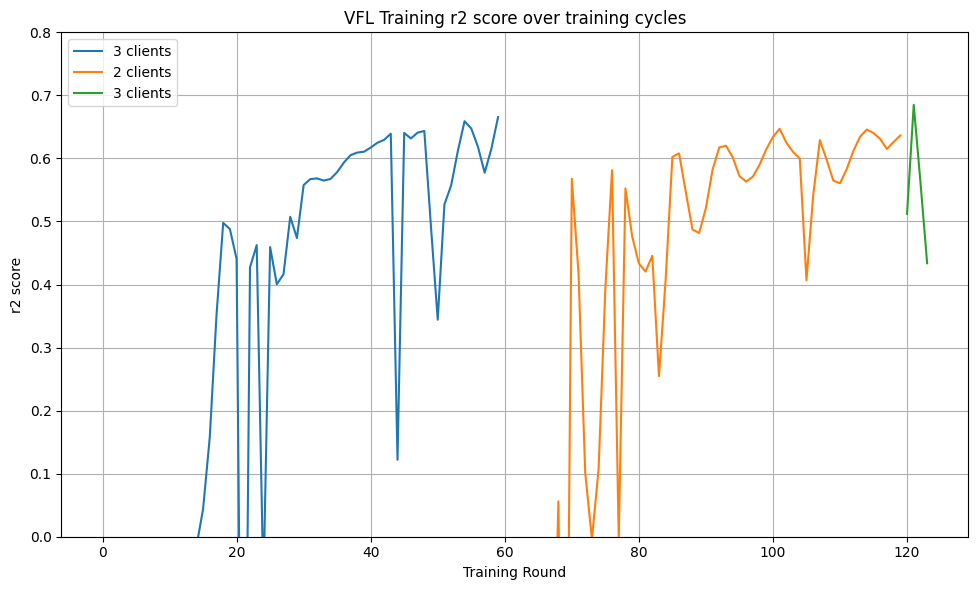

In [ ]:
# SCENARIO TRIGGER !!
scenario_no = 4
res = trigger_scenario(scenario_no)
with open(f"scenario_{scenario_no}.json", 'w') as f :
    json.dump(res, f, indent=2)

In [27]:
# Optional to clean up: uninstall DYNAMOS

command = "helm uninstall agents api-gateway core orchestrator namespaces prometheus thirdparties"
nodes_dict['control']['node'].execute(command)

# Uninstall client and server namespaces (sometimes is needed)
command = "kubectl delete namespace clientone clienttwo clientthree server"
nodes_dict['control']['node'].execute(command)

Error: uninstall: Release not loaded: agents: release: not found
Error from server (NotFound): namespaces "clientone" not found
Error from server (NotFound): namespaces "clienttwo" not found
Error from server (NotFound): namespaces "clientthree" not found
Error from server (NotFound): namespaces "server" not found


('',
 'Error from server (NotFound): namespaces "clientone" not found\nError from server (NotFound): namespaces "clienttwo" not found\nError from server (NotFound): namespaces "clientthree" not found\nError from server (NotFound): namespaces "server" not found\n')

In [28]:
# Optional install DYNAMOS
nodes_dict['control']['node'].execute(f"~/DYNAMOS/configuration/dynamos-configuration.sh")

DYNAMOS configuration v0.1.2
Setting up paths...
definitions_example.json copied over definitions.json to ensure a clean file
Generating RabbitMQ password...
Replacing tokens...
Installing namespaces...
Release "namespaces" does not exist. Installing it now.
NAME: namespaces
LAST DEPLOYED: Thu Nov 20 17:34:50 2025
NAMESPACE: default
STATUS: deployed
REVISION: 1
TEST SUITE: None
Preparing PVC
fill-pvc v0.1.2
pod/temp-pod created
pod/temp-pod-orch created
Waiting for temp-pod to be Running...
pod/temp-pod condition met
pod/temp-pod-orch condition met
pod "temp-pod" deleted
pod "temp-pod-orch" deleted
Installing Prometheus...
"prometheus-community" already exists with the same configuration, skipping
Hang tight while we grab the latest from your chart repositories...
...Successfully got an update from the "prometheus-community" chart repository
Update Complete. ⎈Happy Helming!⎈
Release "prometheus" does not exist. Installing it now.
NAME: prometheus
LAST DEPLOYED: Thu Nov 20 17:35:45 2025

('DYNAMOS configuration v0.1.2\nSetting up paths...\ndefinitions_example.json copied over definitions.json to ensure a clean file\nGenerating RabbitMQ password...\nReplacing tokens...\nInstalling namespaces...\nRelease "namespaces" does not exist. Installing it now.\nNAME: namespaces\nLAST DEPLOYED: Thu Nov 20 17:34:50 2025\nNAMESPACE: default\nSTATUS: deployed\nREVISION: 1\nTEST SUITE: None\nPreparing PVC\nfill-pvc v0.1.2\npod/temp-pod created\npod/temp-pod-orch created\nWaiting for temp-pod to be Running...\npod/temp-pod condition met\npod/temp-pod-orch condition met\npod "temp-pod" deleted\npod "temp-pod-orch" deleted\nInstalling Prometheus...\n"prometheus-community" already exists with the same configuration, skipping\nHang tight while we grab the latest from your chart repositories...\n...Successfully got an update from the "prometheus-community" chart repository\nUpdate Complete. ⎈Happy Helming!⎈\nRelease "prometheus" does not exist. Installing it now.\nNAME: prometheus\nLAST DEP